In [2]:
#se importa librerias 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

#se carga archivo csv
data = pd.read_csv("C:/Users/JGCch/OneDrive/Desktop/Food_products_sales/data/logs_exp_us.csv",sep='\t')

In [3]:
#se valida informacion
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
#se agregan columnas para dar formato a la columna EventTimestamp

#Creamos la columna de fecha y hora (unit ='s': Le dice a pandas que los números representan segundos desde la época Unix)
data['Date_Hour'] = pd.to_datetime(data['EventTimestamp'], unit='s')

#Creamos la columna date donde almacenamos unicamente la fecha del evento
data['Date'] = data['Date_Hour'].dt.date

#creamos la columna hour donde se almacena unicamente la hora del evento
data['Hour'] = data['Date_Hour'].dt.time

In [5]:
#confirmamos df
data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId,Date_Hour,Date,Hour
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25,04:43:36
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25,11:11:42
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25,11:28:47
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25,11:28:47
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25,11:48:42


In [6]:
#Elimino columna EventTimestamp ya que fue desglozada 
data = data.drop('EventTimestamp', axis=1)

#confirmamos df
data.head()

,EventName,DeviceIDHash,ExpId,Date_Hour,Date,Hour
0,MainScreenAppear,4575588528974610257,246,2019-07-25 04:43:36,2019-07-25,04:43:36
1,MainScreenAppear,7416695313311560658,246,2019-07-25 11:11:42,2019-07-25,11:11:42
2,PaymentScreenSuccessful,3518123091307005509,248,2019-07-25 11:28:47,2019-07-25,11:28:47
3,CartScreenAppear,3518123091307005509,248,2019-07-25 11:28:47,2019-07-25,11:28:47
4,PaymentScreenSuccessful,6217807653094995999,248,2019-07-25 11:48:42,2019-07-25,11:48:42


In [8]:
#Renombramos columna para el user ID 
data.rename(columns={'DeviceIDHash':'UserID'}, inplace=True)

In [9]:
#Se reordena las columnas
data = data[['EventName','UserID','Date_Hour','Date','Hour','ExpId']]
data.head()

,EventName,UserID,Date_Hour,Date,Hour,ExpId
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,2019-07-25,04:43:36,246
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,2019-07-25,11:11:42,246
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,2019-07-25,11:28:47,248
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,2019-07-25,11:28:47,248
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,2019-07-25,11:48:42,248


In [10]:
#checamos los tipos de datos despues de cambios
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   EventName  244126 non-null  object        
 1   UserID     244126 non-null  int64         
 2   Date_Hour  244126 non-null  datetime64[ns]
 3   Date       244126 non-null  object        
 4   Hour       244126 non-null  object        
 5   ExpId      244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 11.2+ MB


In [11]:
#cambiamos tipo de dato a las fechas y confirmamos
data['Date'] = pd.to_datetime(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   EventName  244126 non-null  object        
 1   UserID     244126 non-null  int64         
 2   Date_Hour  244126 non-null  datetime64[ns]
 3   Date       244126 non-null  datetime64[ns]
 4   Hour       244126 non-null  object        
 5   ExpId      244126 non-null  int64         
dtypes: datetime64[ns](2), int64(2), object(2)
memory usage: 11.2+ MB


Cuantos eventos hay en los registros?
 EventName
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: EventName, dtype: int64


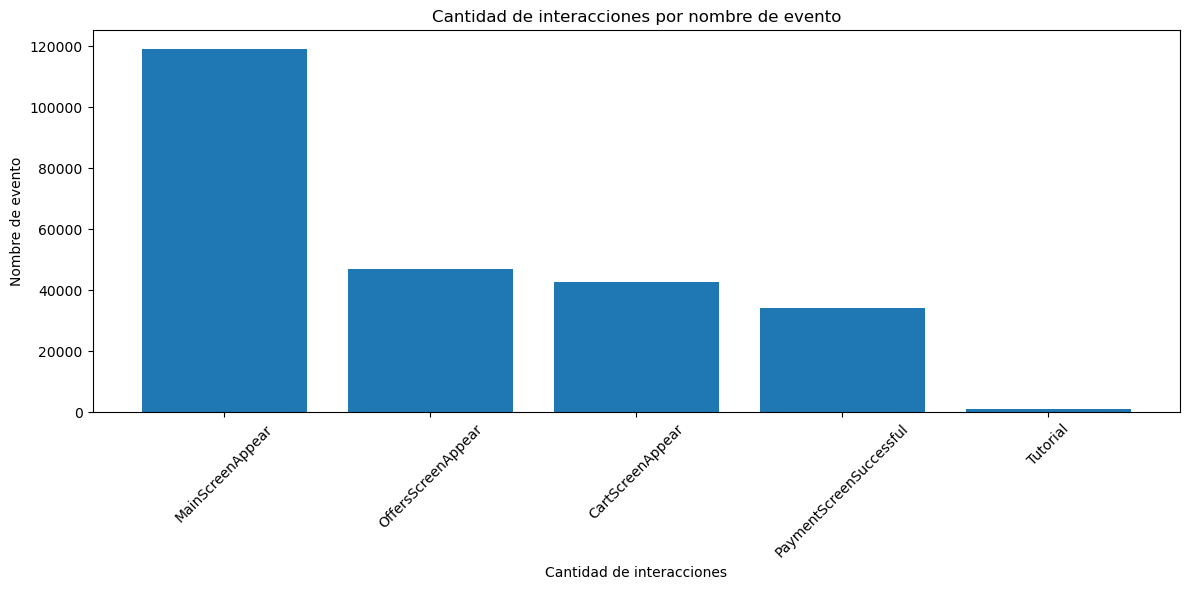

In [12]:
#Agrupamos por nombre del evento y contamos
count_events = data.groupby('EventName')['EventName'].count()
count_events = count_events.sort_values(ascending = False)
print(f'Cuantos eventos hay en los registros?\n',count_events)

#graficamos los resultados
plt.figure(figsize=(12, 6))
plt.bar(count_events.index, count_events.values)
plt.title('Cantidad de interacciones por nombre de evento')
plt.xlabel("Cantidad de interacciones")
plt.ylabel("Nombre de evento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Cuantos usuarios unicos hay en los registros?
 EventName
MainScreenAppear           7439
OffersScreenAppear         4613
CartScreenAppear           3749
PaymentScreenSuccessful    3547
Tutorial                    847
Name: UserID, dtype: int64


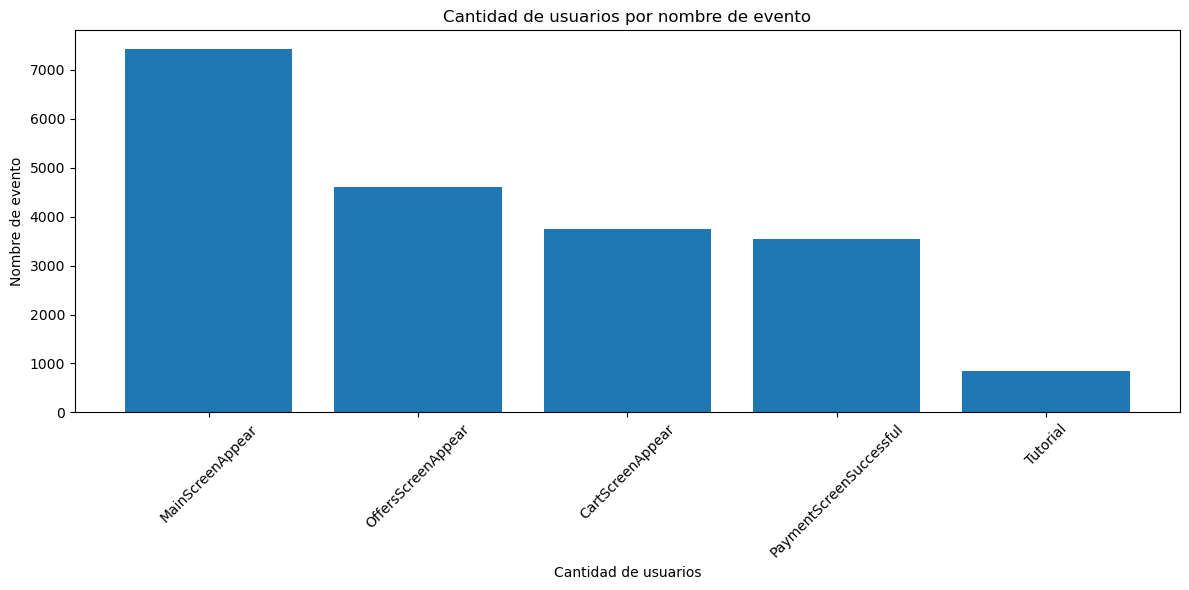

In [13]:
#se cuentan la cantidad de usuarios unicos por evento
count_users = data.groupby('EventName')['UserID'].nunique()
count_users = count_users.sort_values(ascending = False)
print(f'Cuantos usuarios unicos hay en los registros?\n',count_users)

#graficamos resultados
plt.figure(figsize=(12, 6))
plt.bar(count_users.index, count_users.values)
plt.title('Cantidad de usuarios por nombre de evento')
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Nombre de evento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
#Sacamos el promedio de eventos por usuarios
avg_events_per_user = count_events / count_users
print(f'¿Cuál es el promedio de eventos por usuario?\n',avg_events_per_user)

¿Cuál es el promedio de eventos por usuario?
 EventName
MainScreenAppear           16.024331
OffersScreenAppear         10.150661
CartScreenAppear           11.397973
PaymentScreenSuccessful     9.673809
Tutorial                    1.242031
dtype: float64


Con base en la informacion obtenida al momento podemos ver que main screen appear es donde hay mas interacciones con 119 205 ya que un mismo usuario puede entrar en repetidas ocaciones a la pantalla principal y vemos que especificamente de esos 119 205 interacciones solo 7 439 fueron usuarios unicos, es decir solo esos 7 mil de las mas de 100mil interacciones pueden llegar a ser compradores (un usuario puede hacer multiples compras), claro eso va bajando por que vemos en el segundo grafico que solo 3 547 llegaron al apartado de pago exitoso, con el 47% de los usuarios unicos terminan en compras. Tambien podemos observar como la gran perdida de usuarios es entre la pantalla principal y la pantalla de ofertas, vemos una clara perdida del 38% de los usuarios, bajando 2 826 usuarios en esta etapa, en las etapas siguientes si bien sigue bajando la cantidad de usuarios no llega a ser una diferencia tan significativa como las dos primeras etapas. Podemos ver que en promedio el usuario que interactuo con la pantalla principal lo hice 16 veces, pero para llegar a la pantalla de ofertas interactuaron 10 veces en promedio, mientras que al agregar al carrito y realziar la compra son mas cercanos los promedios con 11.39 y 9.67 respectivamente.

In [15]:
#Sacamos el promedio total de eventos por usuarios
total_events = data['EventName'].count() 
total_user_unique = data['UserID'].nunique()
avg_total_events_per_user = total_events / total_user_unique
print(f'¿Cuál es el promedio total de eventos por usuario?\n',avg_total_events_per_user)

¿Cuál es el promedio total de eventos por usuario?
 32.33028737915508


In [16]:
#Periodo de tiempo que cubren los datos
min_date = data['Date'].min()
max_date = data['Date'].max()

print(f'Fecha minima de datos: \n {min_date} \n Fecha maxima de datos: \n {max_date}')

Fecha minima de datos: 
 2019-07-25 00:00:00 
 Fecha maxima de datos: 
 2019-08-07 00:00:00


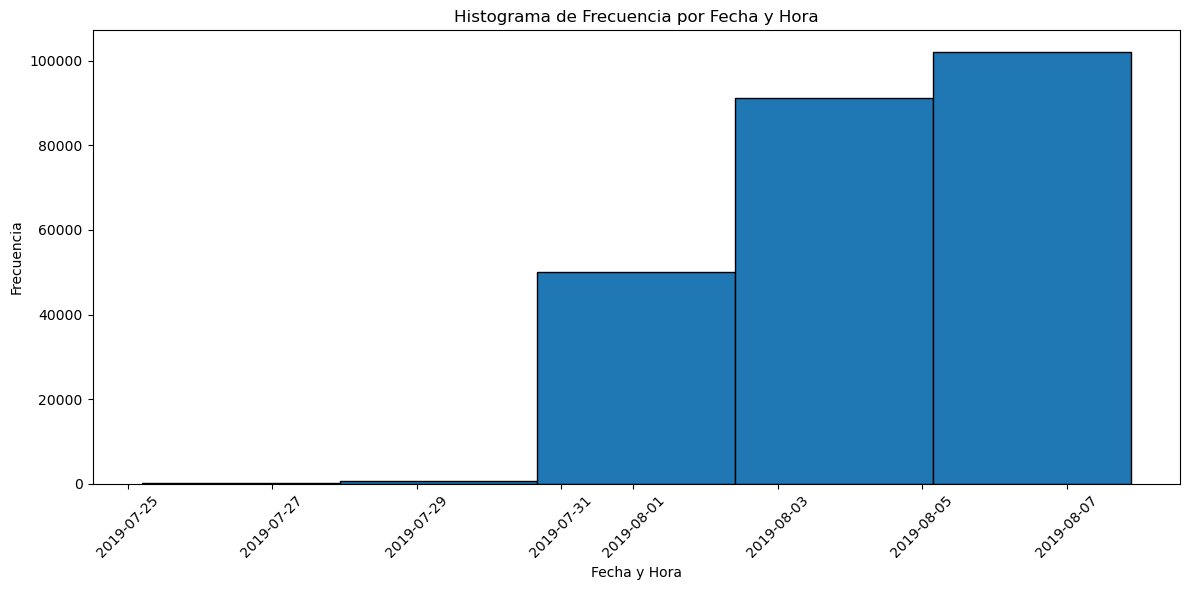

In [17]:
#Graficar histograma
plt.figure(figsize=(12, 6))
plt.hist(data['Date_Hour'], bins=5, edgecolor='black')
plt.title('Histograma de Frecuencia por Fecha y Hora')
plt.xlabel('Fecha y Hora')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Usuarios antes de fecha con mayor frecuencia: 
555 
 Usuarios después de fecha con mayor frecuencia: 
7542


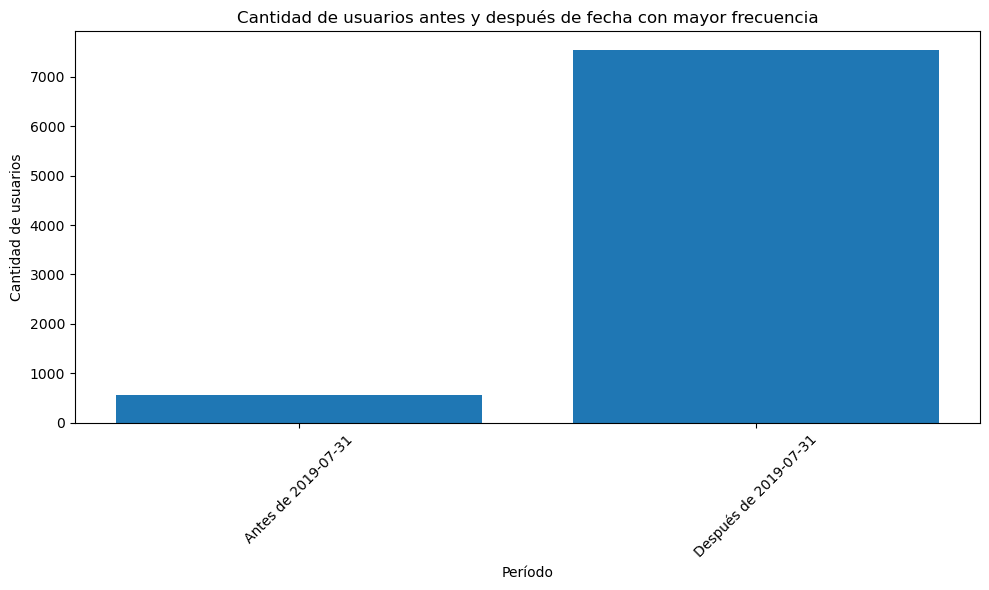

In [18]:
#cantidad de usuarios perdidos al excluir datos antiguos
#establecer fecha limite 
limit_date = '2019-07-31'

#Filtrar y contar antes
before_date = data[data['Date'] < limit_date]['UserID'].nunique()

#Filtrar y contar despues (o igual)
after_date = data[data['Date'] >= limit_date]['UserID'].nunique()

print(f'Usuarios antes de fecha con mayor frecuencia: \n{before_date} \n Usuarios después de fecha con mayor frecuencia: \n{after_date}')

categories = ['Antes de 2019-07-31', 'Después de 2019-07-31']
values = [before_date, after_date]

plt.figure(figsize=(10, 6))
plt.bar(categories, values)
plt.title('Cantidad de usuarios antes y después de fecha con mayor frecuencia')
plt.xlabel("Período")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revisamos las fechas en la que tenemos los datos, establecemos que la fecha minima o donde empiezan los datos es el 25-07-2019 y la fecha hasta la que tenemos informacion es el 07-08-2019, es decir tenemos 14 dias de informacion, al validar con un histograma la frecuencia por las fechas vemos que el impacto real es a partir del 31-07, entonces podriamos decir que donde mas tenemos frecuencia serian 8 dias, siendo los de mayor frecuencia a partir del dia 03 al 07. Podemos observar con base a los numeros mostrados que el impacto de los usuarios que se pierden antes de la fecha donde hay mayor frecuencia no es tan relevante sobre la cantidad de usuarios despues de la fecha ya que los usuarios son mas de 10 veces mas.

In [19]:
print(data['ExpId'].value_counts())

ExpId
248    85747
246    80304
247    78075
Name: count, dtype: int64


In [20]:
#ajustamos el df para que se tengan los datos mas relevantes para el analisis
limit_date = '2019-07-31'
limit_date = pd.to_datetime(limit_date)
data = data[data['Date']>=limit_date].reset_index(drop=True)

data.head()

,EventName,UserID,Date_Hour,Date,Hour,ExpId
0,MainScreenAppear,3670880358399219515,2019-07-31 01:11:46,2019-07-31,01:11:46,247
1,OffersScreenAppear,3799109751993694887,2019-07-31 01:21:04,2019-07-31,01:21:04,248
2,Tutorial,1126021718529336913,2019-07-31 01:32:11,2019-07-31,01:32:11,247
3,MainScreenAppear,4293428370257583636,2019-07-31 02:19:18,2019-07-31,02:19:18,248
4,MainScreenAppear,4567464647598975872,2019-07-31 02:33:30,2019-07-31,02:33:30,247


In [21]:
#ordenamos eventos
frequency = {}
for event in data['EventName']:
    frequency[event] = frequency.get(event, 0) + 1

#Ordenar por valor (frecuencia) descendentemente
sort_events = sorted(frequency.items(), key=lambda item: item[1], reverse=True)

sort_events

[('MainScreenAppear', 118681),
 ('OffersScreenAppear', 46724),
 ('CartScreenAppear', 42623),
 ('PaymentScreenSuccessful', 34253),
 ('Tutorial', 1048)]

In [22]:
#contamos usuarios unicos
count_users = data.groupby('EventName')['UserID'].nunique()
count_users = count_users.sort_values(ascending = False)

total_unique_users = data['UserID'].nunique()

#obtenemos la proporcion de usuarios 
proportion = count_users / total_unique_users

print("=== ANALISIS DE USUARIOS POR EVENTO ===")
print(f'Total de usuarios únicos: {total_unique_users}')
print('\nUsuarios únicos por evento:')
for event, users in count_users.items():
    prop = proportion[event]
    print(f"{event}: {users} usuarios ({prop:.2%})")

=== ANALISIS DE USUARIOS POR EVENTO ===
Total de usuarios únicos: 7542

Usuarios únicos por evento:
MainScreenAppear: 7429 usuarios (98.50%)
OffersScreenAppear: 4606 usuarios (61.07%)
CartScreenAppear: 3742 usuarios (49.62%)
PaymentScreenSuccessful: 3542 usuarios (46.96%)
Tutorial: 845 usuarios (11.20%)


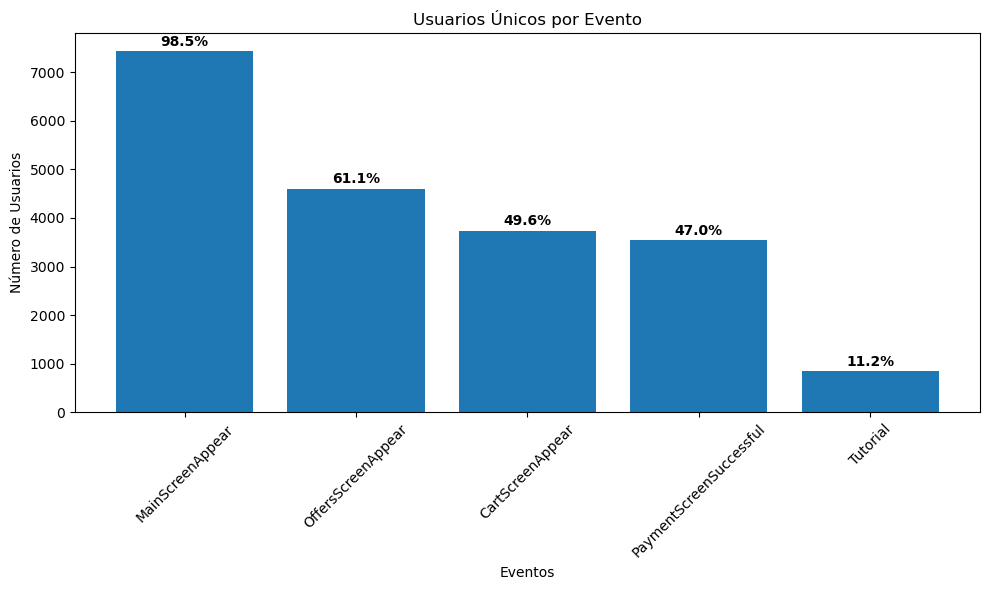

In [23]:
#mostramos graficamente el porcentaje de usuarios 
plt.figure(figsize=(10, 6))
plt.bar(count_users.index, count_users.values)
for i, (event, users) in enumerate(count_users.items()):
    percentage = (users / total_unique_users) * 100
    plt.text(i, users + 50, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontweight='bold')
plt.title('Usuarios Únicos por Evento')
plt.xlabel('Eventos')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Orden en que ocurren las acciones##

MainScreenAppear → Pantalla princi (118,681 usuarios)
OffersScreenAppear → Pantalla de ofertas (46,724 usuarios)
CartScreenAppear → Carrito de compras (42,623 usuarios)
PaymentScreenSuccessful → Compra exitosa (34,253 usuarios)
Tutorial: Evento independiente/opcional que no forma parte del embudo principal

Con base al analisis anterior podemos observar la proporcion de usuarios que van pasado en cada evento, en donde vemos como ya se habia mencionado anteriormente donde se pierde la mayor cantidad de usuarios es entre la pantalla principal y la pantalla de ofertas, donde se pierde practicamente el 40% de los usuarios, a partir de esta pantalla la perdida de usuarios es mucho menor y la proporcion entre los que entran a la pantalla del carrito y la pantalla de pago es muy parecida por lo que podemos dedudicr que los usuarios que se llevan productos al carrito e ingresan a esa pantalla pasan a realizar la compra.

In [24]:
#Cuantos usuarios hay en cada grupo?
#agrupamos usuarios por grupo o numero de experimento y se ordenan los valores
users_per_group = data.groupby('ExpId')['UserID'].nunique()
users_per_group = users_per_group.sort_values(ascending = False)

users_per_group

ExpId
248    2540
247    2517
246    2485
Name: UserID, dtype: int64

In [25]:
#definir los datos 
#conversiones y usuarios totales de cada grupo
success_data_246 = data[(data['ExpId']==246) & (data['EventName']=='PaymentScreenSuccessful')]['UserID'].nunique()
total_unique_users_246 = data[data['ExpId']==246]['UserID'].nunique()

success_data_247 = data[(data['ExpId']==247) & (data['EventName']=='PaymentScreenSuccessful')]['UserID'].nunique()
total_unique_users_247 = data[data['ExpId']==247]['UserID'].nunique()

count = np.array([success_data_246, success_data_247])
nobs = np.array([total_unique_users_246, total_unique_users_247])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"Muestra 246 conversión: {success_data_246/total_unique_users_246:.2f}")
print(f"Muestra 247 conversión: {success_data_247/total_unique_users_247:.2f}")
print(f"---")
print(f"p-value: {p_value:.2f}")

#Interpretación
alpha = 0.05
if p_value < alpha:
    print("\nRESULTADO: Diferencia estadísticamente significativa")
    print("¡Cuidado! El test A/A muestra diferencias, revisa los mecanismos.")
else:
    print("\nRESULTADO: No hay diferencia estadísticamente significativa")
    print("El test A/A es correcto.")

Muestra 246 conversión: 0.48
Muestra 247 conversión: 0.46
---
p-value: 0.11

RESULTADO: No hay diferencia estadísticamente significativa
El test A/A es correcto.


In [26]:
def compare_groups(data, group1, group2, event_name='PaymentScreenSuccessful'):
    """
    Compara las tasas de conversión entre dos grupos experimentales
    
    Parámetros:
    - data: DataFrame con los datos
    - group1: ID del primer grupo experimental (int o lista)
    - group2: ID del segundo grupo experimental (int o lista)
    - event_name: Nombre del evento a analizar
    
    Retorna:
    - p_value: valor p de la prueba
    """
    
    # Convertir a listas si son números individuales
    if isinstance(group1, int):
        group1 = [group1]
    if isinstance(group2, int):
        group2 = [group2]
    
    # Conversiones por grupo (USAR .isin() para listas)
    success_group1 = data[(data['ExpId'].isin(group1)) & (data['EventName']==event_name)]['UserID'].nunique()
    success_group2 = data[(data['ExpId'].isin(group2)) & (data['EventName']==event_name)]['UserID'].nunique()
    
    # Usuarios totales por grupo
    total_group1 = data[data['ExpId'].isin(group1)]['UserID'].nunique()
    total_group2 = data[data['ExpId'].isin(group2)]['UserID'].nunique()
    
    # Preparar datos para z-test
    count = np.array([success_group1, success_group2])
    nobs = np.array([total_group1, total_group2])
    
    # Realizar z-test
    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    # Mostrar resultados
    print(f"Grupo {group1} conversión: {success_group1}/{total_group1} = {success_group1/total_group1:.4f}")
    print(f"Grupo {group2} conversión: {success_group2}/{total_group2} = {success_group2/total_group2:.4f}")
    print(f"---")
    print(f"p-value: {p_value:.4f}")
    
    #Interpretación
    alpha = 0.05
    if p_value < alpha:
        print(f"\nRESULTADO: Diferencia estadísticamente significativa")
    else:
        print(f"\nRESULTADO: No hay diferencia estadísticamente significativa")
    
    return p_value

In [27]:
#pruebas individuales
#test A/A (grupos de control)
print("=== TEST A/A (246 vs 247) ===")
p_value_aa = compare_groups(data, 246, 247)

print("\n" + "="*50 + "\n")


#test A/B (control vs experimental)
print("=== TEST A/B (247 vs 248) ===")
p_value_ab = compare_groups(data, 247, 248)


=== TEST A/A (246 vs 247) ===
Grupo [246] conversión: 1200/2485 = 0.4829
Grupo [247] conversión: 1159/2517 = 0.4605
---
p-value: 0.1121

RESULTADO: No hay diferencia estadísticamente significativa


=== TEST A/B (247 vs 248) ===
Grupo [247] conversión: 1159/2517 = 0.4605
Grupo [248] conversión: 1183/2540 = 0.4657
---
p-value: 0.7066

RESULTADO: No hay diferencia estadísticamente significativa


In [28]:
#test A/B (control vs grupo)
print("=== TEST A/B (248 vs [246,247]) ===")
p_value_ab = compare_groups(data, 248, [246,247])


=== TEST A/B (248 vs [246,247]) ===
Grupo [248] conversión: 1183/2540 = 0.4657
Grupo [246, 247] conversión: 2359/5002 = 0.4716
---
p-value: 0.6297

RESULTADO: No hay diferencia estadísticamente significativa


In [29]:
#Se repite funcion y pruebas con nivel de signficancia o valor alpha = 0.01

#Se crea funcion para comparar diferentes eventos.

def compare_groups(data, group1, group2, event_name='PaymentScreenSuccessful'):
    """
    Compara las tasas de conversión entre dos grupos experimentales
    
    Parámetros:
    - data: DataFrame con los datos
    - group1: ID del primer grupo experimental
    - group2: ID del segundo   
    - event_name: Nombre del evento a agrupo experimentalnalizar (por defecto PaymentScreenSuccessful)
    
    Retorna:
    - p_value: valor p de la prueba
    """
    
    # Conversiones por grupo
    success_group1 = data[(data['ExpId']==group1) & (data['EventName']==event_name)]['UserID'].nunique()
    success_group2 = data[(data['ExpId']==group2) & (data['EventName']==event_name)]['UserID'].nunique()
    
    # Usuarios totales por grupo
    total_group1 = data[data['ExpId']==group1]['UserID'].nunique()
    total_group2 = data[data['ExpId']==group2]['UserID'].nunique()
    
    # Preparar datos para z-test
    count = np.array([success_group1, success_group2])
    nobs = np.array([total_group1, total_group2])
    
    # Realizar z-test
    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    # Mostrar resultados
    print(f"Grupo {group1} conversión: {success_group1}/{total_group1} = {success_group1/total_group1:.4f}")
    print(f"Grupo {group2} conversión: {success_group2}/{total_group2} = {success_group2/total_group2:.4f}")
    print(f"---")
    print(f"p-value: {p_value:.4f}")
    
    # Interpretación
    alpha = 0.01
    if p_value < alpha:
        print(f"\nRESULTADO: Diferencia estadísticamente significativa")
        if group1 == 246 and group2 == 247:
            print("¡Cuidado! El test A/A muestra diferencias, revisa los mecanismos.")
        else:
            print("Hay diferencia significativa entre los grupos.")
    else:
        print(f"\nRESULTADO: No hay diferencia estadísticamente significativa")
        if group1 == 246 and group2 == 247:
            print("El test A/A es correcto.")
        else:
            print("No hay diferencia significativa entre los grupos.")
    
    return p_value

In [30]:
#test A/A (grupos de control)
print("=== TEST A/A (246 vs 247) ===")
p_value_aa = compare_groups(data, 246, 247)

print("\n" + "="*50 + "\n")

#test A/B (control vs experimental)
print("=== TEST A/B (247 vs 248) ===")
p_value_ab = compare_groups(data, 247, 248)

=== TEST A/A (246 vs 247) ===
Grupo 246 conversión: 1200/2485 = 0.4829
Grupo 247 conversión: 1159/2517 = 0.4605
---
p-value: 0.1121

RESULTADO: No hay diferencia estadísticamente significativa
El test A/A es correcto.


=== TEST A/B (247 vs 248) ===
Grupo 247 conversión: 1159/2517 = 0.4605
Grupo 248 conversión: 1183/2540 = 0.4657
---
p-value: 0.7066

RESULTADO: No hay diferencia estadísticamente significativa
No hay diferencia significativa entre los grupos.
